Статья, изменившая мир DL: [Attention Is All You Need](https://arxiv.org/pdf/1706.03762.pdf)

Очень сильно советую посмотреть эти лекции от Евгения Разинкова (они на русском):
1. [Введение в Vision Transformer](https://www.youtube.com/watch?v=yt_pOBFHu2g&list=PL6-BrcpR2C5Szpo6RS370Ck1_-emlwlWc&index=12&pp=iAQB)
2. [Архитектура ViT](https://www.youtube.com/watch?v=Bh-xYw2cYfQ&list=PL6-BrcpR2C5Szpo6RS370Ck1_-emlwlWc&index=14)

И вообще в целом [весь плейлист лекций про DL](https://www.youtube.com/playlist?list=PL6-BrcpR2C5Szpo6RS370Ck1_-emlwlWc) хорошо прочитан и много всего разжевано.

# Attention

## SDPA (Scaled Dot-Product Attention)

<img src="https://i2.wp.com/miro.medium.com/1*I-VlqUAk23uHVVcxbrqTHA.jpeg" alt="drawing" height="300"/>

<img src="http://data-science-blog.com/wp-content/uploads/2022/01/self_attention_map-1536x355.png" alt="drawing" height="200"/>

In [ ]:
import torch
import torch.nn.functional as F
import math

In [ ]:
torch.manual_seed(0)

# Q = q x k - q запросов, каждый из запросов это вектор размера k
# K = n x k - n ключей (и соответственно строчек) в таблице, каждый из ключей это вектор размера k
# V = n x m - n значений в таблице, каждое из значений это вектор размера m

q = 1
k = 2
n = 3
m = 4

Q = torch.randint(10, (q, k), dtype=torch.float32)
K = torch.randint(10, (n, k), dtype=torch.float32)
V = torch.randint(10, (n, m), dtype=torch.float32)

In [ ]:
Q

tensor([[4., 9.]])

In [ ]:
K

tensor([[3., 0.],
        [3., 9.],
        [7., 3.]])

In [ ]:
V

tensor([[7., 3., 1., 6.],
        [6., 9., 8., 6.],
        [6., 8., 4., 3.]])

In [ ]:
Q @ K.T

tensor([[12., 93., 55.]])

In [ ]:
scale = math.sqrt(k)
W1 = Q @ K.T / scale
W1

tensor([[ 8.4853, 65.7609, 38.8909]])

In [ ]:
W = F.softmax(W1, dim=-1)
W

tensor([[1.3351e-25, 1.0000e+00, 2.1403e-12]])

In [ ]:
W @ V

tensor([[6., 9., 8., 6.]])

In [ ]:
def my_SDPA(Q, K, V):
  k = K.shape[-1]
  scale = math.sqrt(k)
  W1 = Q @ K.T / scale
  W = F.softmax(W1, dim=-1)
  return W @ V, W

In [ ]:
my_SDPA(Q, K, V)

(tensor([[6., 9., 8., 6.]]), tensor([[1.3351e-25, 1.0000e+00, 2.1403e-12]]))

In [ ]:
F.scaled_dot_product_attention(Q, K, V)

tensor([[6., 9., 8., 6.]])

### Пример, когда запросов несколько

In [ ]:
q = 6
k = 3
n = 4
m = 5

Q = torch.randint(10, (q, k), dtype=torch.float32)
K = torch.randint(10, (n, k), dtype=torch.float32)
V = torch.randint(10, (n, m), dtype=torch.float32)

In [ ]:
Q

tensor([[6., 9., 1.],
        [4., 4., 1.],
        [9., 9., 9.],
        [0., 1., 2.],
        [3., 0., 5.],
        [5., 2., 9.]])

In [ ]:
K

tensor([[1., 8., 8.],
        [3., 6., 9.],
        [1., 7., 3.],
        [5., 2., 1.]])

In [ ]:
V

tensor([[0., 9., 3., 1., 1.],
        [0., 3., 6., 6., 7.],
        [9., 6., 3., 4., 5.],
        [0., 8., 2., 8., 2.]])

In [ ]:
res, attn_weights = my_SDPA(Q, K, V)

In [ ]:
res

tensor([[2.6314e-03, 8.6823e+00, 3.1584e+00, 1.2649e+00, 1.3180e+00],
        [1.7883e-02, 5.1591e+00, 4.9174e+00, 4.2021e+00, 4.8429e+00],
        [1.4296e-15, 3.0330e+00, 5.9835e+00, 5.9725e+00, 6.9670e+00],
        [7.8468e-03, 6.0000e+00, 4.4987e+00, 3.5005e+00, 4.0009e+00],
        [8.4498e-09, 3.0105e+00, 5.9948e+00, 5.9913e+00, 6.9895e+00],
        [2.5603e-15, 3.0010e+00, 5.9995e+00, 5.9991e+00, 6.9990e+00]])

In [ ]:
F.scaled_dot_product_attention(Q, K, V)

tensor([[2.6314e-03, 8.6823e+00, 3.1584e+00, 1.2649e+00, 1.3180e+00],
        [1.7883e-02, 5.1591e+00, 4.9174e+00, 4.2021e+00, 4.8429e+00],
        [1.4296e-15, 3.0330e+00, 5.9835e+00, 5.9725e+00, 6.9670e+00],
        [7.8468e-03, 6.0000e+00, 4.4987e+00, 3.5005e+00, 4.0009e+00],
        [8.4498e-09, 3.0105e+00, 5.9948e+00, 5.9913e+00, 6.9895e+00],
        [2.5603e-15, 3.0010e+00, 5.9995e+00, 5.9991e+00, 6.9990e+00]])

#### Визулизация attn_weights

In [ ]:
attn_weights

tensor([[9.4691e-01, 5.2797e-02, 2.9238e-04, 4.9995e-10],
        [3.5881e-01, 6.3915e-01, 1.9870e-03, 6.2196e-05],
        [5.5073e-03, 9.9449e-01, 1.5885e-16, 2.6977e-23],
        [4.9956e-01, 4.9956e-01, 8.7186e-04, 4.8282e-06],
        [1.7422e-03, 9.9826e-01, 9.3886e-10, 2.9791e-09],
        [1.7331e-04, 9.9983e-01, 2.8447e-16, 2.8062e-18]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention_weights(attn_weights):
    attn_weights = np.array(attn_weights)

    plt.figure(figsize=(8, 5))
    plt.imshow(attn_weights, cmap='gray', interpolation='nearest')

    plt.colorbar()

    plt.title('Вектора внимания для каждого из запросов')

    plt.show()

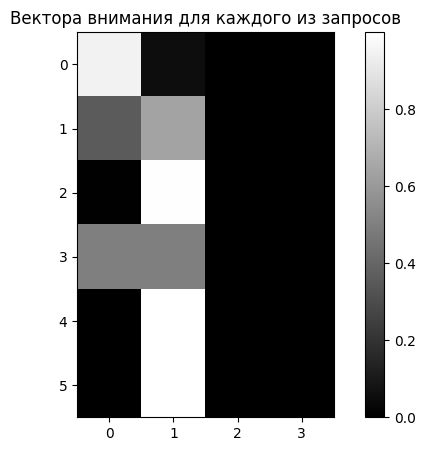

In [ ]:
visualize_attention_weights(attn_weights)

## MHA (Multi-Head Attention)

<img src="https://cdn-uploads.huggingface.co/production/uploads/6527e89a8808d80ccff88b7a/OR1FEX7gJ4XlDKXhRvLsk.png" alt="drawing" height="400"/>

In [ ]:
import torch
import math

def my_SDPA(Q, K, V, scale=None):
    scale = math.sqrt(K.shape[-1]) if scale is None else scale
    W1 = Q @ K.transpose(-2, -1) / scale
    W = F.softmax(W1, dim=-1)
    return W @ V, W

class MyMHA(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, bias=False):
        # embed_dim = 768
        # num_heads = 8

        super().__init__()
        self.bias = bias

        self.in_proj_weight = torch.nn.Parameter(torch.empty((3 * embed_dim, embed_dim)))
        torch.nn.init.xavier_uniform_(self.in_proj_weight)

        self.in_proj_bias = torch.nn.Parameter(torch.zeros(3 * embed_dim), requires_grad=bias)

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"

        self.scale = math.sqrt(self.head_dim)

        self.out_proj = torch.nn.Linear(embed_dim, embed_dim, bias=bias)

    def forward(self, q, k, v, average_attn_weights=False):
        packed_in_proj_w = self.in_proj_weight.chunk(3) # 3 x embed_dim x embed_dim
        packed_in_proj_b = self.in_proj_bias.chunk(3) # 3 x embed_dim

        bs, N_len, E = q.shape
        qkv_in_projected = list(map(lambda x: x[0] @ x[1].T + x[2],
                        zip([q, k, v], packed_in_proj_w, packed_in_proj_b)))
        # q.shape = bs x N x embed_dim
        q, k, v = list(map(lambda x:
                           x.view(bs, N_len, self.num_heads, self.head_dim).transpose(-3, -2),
                           qkv_in_projected))
        # q.shape = bs x num_heads x N x head_dim
        out1, attn_output_weights = my_SDPA(q, k, v, self.scale)
        # out1.shape = bs x num_heads x N x head_dim
        out2 = out1.transpose(-3, -2).reshape(bs, N_len, -1)
        # out2.shape = bs x N x embed_dim
        out3 = self.out_proj(out2)
        if average_attn_weights:
            attn_output_weights = attn_output_weights.mean(dim=1)
        return out3, attn_output_weights

In [ ]:
bs, N_len, embed_dim = in_shape = (3, 7, 512)

q = torch.randn(in_shape)
k = torch.randn(in_shape)
v = torch.randn(in_shape)

num_heads = 4
bias = False
average_attn_weights = False

torch_MHA = torch.nn.MultiheadAttention(embed_dim, num_heads,
                                        batch_first=True, bias=bias)
my_MHA = MyMHA(embed_dim, num_heads, bias=bias)

my_MHA.in_proj_weight.data = torch_MHA.in_proj_weight.data
my_MHA.out_proj.weight.data = torch_MHA.out_proj.weight.data
if bias:
    my_MHA.in_proj_bias.data = torch_MHA.in_proj_bias.data
    my_MHA.out_proj.bias.data = torch_MHA.out_proj.bias.data

In [ ]:
torch_attn_output, torch_attn_weights = torch_MHA(q, k, v,
                                                  average_attn_weights=average_attn_weights)
my_attn_output, my_attn_weights = my_MHA(q, k, v,
                                         average_attn_weights=average_attn_weights)

assert torch.nn.functional.mse_loss(torch_attn_output, my_attn_output) < 0.000001, \
            "---- Forward attn_output: test failed :("
print("++++ Forward attn_output: test passed!")

assert torch.nn.functional.mse_loss(torch_attn_weights, my_attn_weights) < 0.000001, \
    "---- Forward attn_weights: test failed :("
print("++++ Forward attn_weights: test passed!")

++++ Forward attn_output: test passed!
++++ Forward attn_weights: test passed!


In [ ]:
torch_attn_output.shape

torch.Size([3, 7, 512])

# ViT (Vision Transformer)

Paper: https://arxiv.org/pdf/2010.11929.pdf

ViT from scratch: https://github.com/lucidrains/vit-pytorch/blob/main/vit_pytorch/vit.py

<img src="https://i.postimg.cc/907rsLzj/vit-arch.png" alt="drawing" height="500"/>

In [ ]:
import torchvision
from torchvision import transforms as T

In [ ]:
from PIL import Image
import requests
from io import BytesIO

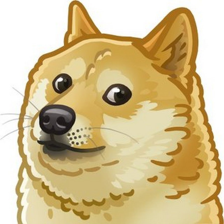

In [ ]:
url = 'https://bogatyr.club/uploads/posts/2023-03/1679320325_bogatyr-club-p-sobaka-na-zheltom-fone-foni-vkontakte-75.jpg'
response = requests.get(url)
pil_img = Image.open(BytesIO(response.content)).convert('RGB').resize((224, 224))
pil_img

In [ ]:
patch_size = 16
patch_stride = 16
x = T.ToTensor()(pil_img)[None, :]
x = x.permute((0, 2, 3, 1))
patches = x.unfold(1, patch_size, patch_stride).unfold(2, patch_size, patch_stride)
patches.shape

torch.Size([1, 14, 14, 3, 16, 16])

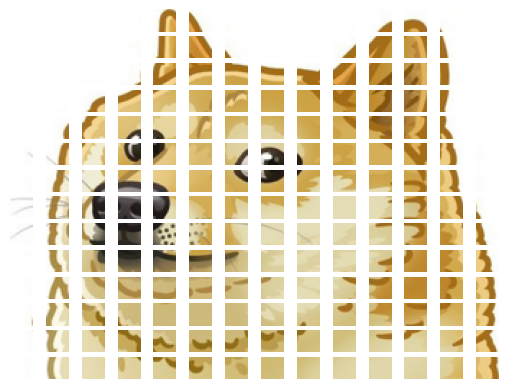

In [ ]:
import matplotlib.pyplot as plt

images = patches[0]

fig, axes = plt.subplots(len(images), len(images[0]))

for i in range(len(images)):
    for j in range(len(images[i])):
        np_image = images[i][j].numpy()
        transposed_image = np_image.transpose(1, 2, 0)
        axes[i, j].imshow(transposed_image)
        axes[i, j].axis('off')
""
plt.show()

In [ ]:
def img_to_patches(img, patch_size=16, patch_stride=16):
    batch_size, C, W, H = img.shape
    img = img.permute((0, 2, 3, 1))
    patches = img.unfold(1, patch_size, patch_stride).unfold(2, patch_size, patch_stride)
    patches = patches.reshape((batch_size, (W // patch_size) * (H // patch_stride), -1))
    return patches

In [ ]:
import torch
from torch import nn, optim

class ViT_Encoder_Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super(ViT_Encoder_Block, self).__init__()
        self.heads = num_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.MHA = nn.MultiheadAttention(d_model, num_heads=num_heads, batch_first=True)

        self.out_layers = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        # x.shape = bs x 197 x d_model
        out1 = self.layer_norm(x)

        attn_output, _ = self.MHA(out1, out1, out1)

        out2 = attn_output + x
        out3 = self.out_layers(out2)
        return out3 + out2


class ViT_Classifier(nn.Module):
    def __init__(self, num_classes, channels=3, img_width=224, img_height=224,
                 patch_size=16, patch_stride=16,
                 d_model=768, num_layers=8, num_heads=12):
        super(ViT_Classifier, self).__init__()
        self.channels = channels
        self.img_width = img_width
        self.img_height = img_height
        self.patch_size = patch_size
        self.patch_stride = patch_stride

        self.cls_token = nn.Parameter(torch.randn(d_model))
        self.PEs = nn.Parameter(torch.randn(197, d_model))
        self.fc = nn.Linear(channels * patch_size * patch_stride, d_model)
        self.layers = nn.Sequential(*[ViT_Encoder_Block(d_model, num_heads) for _ in range(num_layers)])
        self.end_FC = nn.Linear(d_model, num_classes)

    def forward(self, img):
        # img.shape = bs x 3 x 224 x 224
        x = img_to_patches(img, self.patch_size, self.patch_stride)
        # x.shape = bs x 196 x 768
        x = self.fc(x)
        # x.shape = bs x 196 x d_model
        batch_sz = img.shape[0]
        token = self.cls_token.repeat(batch_sz, 1, 1)
        x_embed = torch.cat((token, x), dim=1)
        # x_embed.shape = bs x 197 x d_model
        x_embed_pos = x_embed + self.PEs
        out = self.layers(x_embed_pos)
        out = self.end_FC(out[:, 0])
        return out

## Скачиваем датасет из Kaggle

In [ ]:
!pip install -q kaggle

In [ ]:
import os
kaggle_token = {"username":"izhanvarsky", "key":"e06d966b7ebc01cb2eaeec716e2d1cf0"}

os.environ['KAGGLE_USERNAME'] = kaggle_token['username']
os.environ['KAGGLE_KEY'] = kaggle_token['key']

In [ ]:
# https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

 99% 777M/788M [00:10<00:00, 84.1MB/s]
100% 788M/788M [00:10<00:00, 77.4MB/s]


In [ ]:
!unzip -q microsoft-catsvsdogs-dataset.zip

In [ ]:
# https://stackoverflow.com/questions/63425209/cannot-identify-image-file-while-trying-to-use-tensorflow-on-google-collab

from PIL import Image, ImageFile
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

def validate_images(folder_path):
    for root, dirs, files in os.walk(folder_path):
        print(f"Cur dir: {root}")
        for file in tqdm(files):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(root, file)
                try:
                  img = Image.open(image_path)
                  img.load()
                  img.close()
                except Exception as e:
                  print(f"Image is incorrect: {image_path}")
                  print(e)
                  os.remove(image_path)

In [ ]:
validate_images('./PetImages')

!rm "./PetImages/Dog/9057.jpg"
!rm "./PetImages/Dog/11702.jpg"
!rm "./PetImages/Cat/666.jpg"

Cur dir: ./PetImages


0it [00:00, ?it/s]


Cur dir: ./PetImages/Cat


 92%|█████████▏| 11449/12501 [00:25<00:01, 842.25it/s]

Image is incorrect: ./PetImages/Cat/666.jpg
cannot identify image file './PetImages/Cat/666.jpg'


...

Cur dir: ./PetImages/Dog


  7%|▋         | 842/12501 [00:01<00:13, 839.71it/s]

Image is incorrect: ./PetImages/Dog/11702.jpg
cannot identify image file './PetImages/Dog/11702.jpg'


 50%|█████     | 6297/12501 [00:07<00:07, 806.87it/s]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 12501/12501 [00:17<00:00, 718.45it/s]


rm: cannot remove './PetImages/Dog/11702.jpg': No such file or directory
rm: cannot remove './PetImages/Cat/666.jpg': No such file or directory


In [ ]:
from tqdm import tqdm
import random

def split_dataset(dataset_root, test_ratio=0.05):
    out_train_fname = 'train.csv'
    out_test_fname = 'test.csv'
    print("Running splitting dataset to Train and Test")
    print(f"test_ratio: {test_ratio}")
    print(f"dataset_root: {dataset_root}")
    print(f"out_train_fname: {out_train_fname}")
    print(f"out_test_fname: {out_test_fname}")

    classes = os.listdir(dataset_root)
    out_train_files = []
    out_test_files = []
    for cls in tqdm(classes):
        cur_dir = f'{dataset_root}/{cls}'
        if not os.path.isdir(cur_dir):
            continue
        img_names = [fname for fname in os.listdir(cur_dir)
                     if fname.lower().endswith(('.jpg', '.jpeg', '.png'))]
        test_size = int(len(img_names) * test_ratio)
        test_files = random.sample(img_names, test_size)
        for img_name in img_names:
            p = f'{cls},{img_name}\n'
            if img_name in test_files:
                out_test_files.append(p)
            else:
                out_train_files.append(p)
    with open(f'{dataset_root}/{out_train_fname}', 'w') as f:
        f.writelines(out_train_files)
    print(f'Number of train images: {len(out_train_files)}')
    with open(f'{dataset_root}/{out_test_fname}', 'w') as f:
        f.writelines(out_test_files)
    print(f'Number of test images: {len(out_test_files)}')

In [ ]:
dataset_root = './PetImages'
split_dataset(dataset_root, 0.1)

Running splitting dataset to Train and Test
test_ratio: 0.1
dataset_root: ./PetImages
out_train_fname: train.csv
out_test_fname: test.csv


100%|██████████| 2/2 [00:00<00:00,  3.04it/s]

Number of train images: 22499
Number of test images: 2498


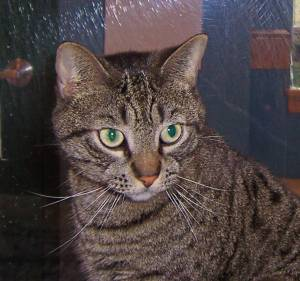

In [ ]:
Image.open(f'{dataset_root}/Cat/1.jpg')

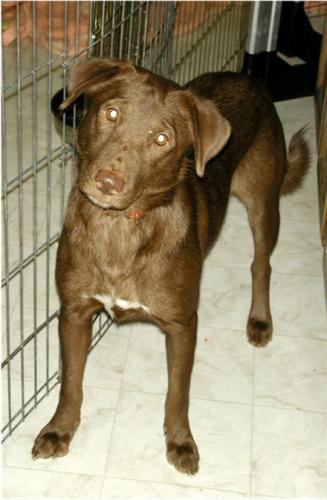

In [ ]:
Image.open(f'{dataset_root}/Dog/1.jpg')

## Аугментации

In [ ]:
from torchvision import transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
img_sz = 224

normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_data_transforms = T.Compose([
        T.Resize((img_sz, img_sz)),
        T.RandomHorizontalFlip(),
        # T.RandomRotation(degrees=30),
        # T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        T.ToTensor(),
        normalize
    ])
test_data_transforms = T.Compose([
    T.Resize((img_sz, img_sz)),
    T.ToTensor(),
    normalize
])

## ImageDatasets

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd

class ImageDataset(Dataset):
    def __init__(self, dataset_root, csv_filename, transform):
        print("Reading Image Dataset...")
        self.dataset_root = dataset_root
        self.classes = sorted([name for name in os.listdir(self.dataset_root)
                               if os.path.isdir(f'{self.dataset_root}/{name}')])
        self.label_to_idx = {val: idx for idx, val in enumerate(self.classes)}

        print("Reading dataset file paths...")
        self.img_labels = pd.read_csv(f'{dataset_root}/{csv_filename}', delimiter=',')
        self.transform = transform
        print("Image Dataset instance created!")

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, index):
        label = self.img_labels.iloc[index, 0]
        img_name = self.img_labels.iloc[index, 1]
        img_path = f'{self.dataset_root}/{label}/{img_name}'
        image = Image.open(img_path).convert('RGB')

        image_tensor = self.transform(image)
        image.close()
        return image_tensor, self.label_to_idx[label]

In [ ]:
image_datasets = dict()
image_datasets['train'] = ImageDataset(dataset_root=dataset_root,
                                       csv_filename='train.csv',
                                       transform=train_data_transforms)
image_datasets['test'] = ImageDataset(dataset_root=dataset_root,
                                       csv_filename='test.csv',
                                       transform=test_data_transforms)

Reading Image Dataset...
Reading dataset file paths...
Image Dataset instance created!
Reading Image Dataset...
Reading dataset file paths...
Image Dataset instance created!


## Dataloaders

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2

dataloaders = dict()
dataloaders['train'] = DataLoader(image_datasets['train'],
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=num_workers,
                                  pin_memory=True,
                                  drop_last=True)
dataloaders['test'] = DataLoader(image_datasets['test'],
                                  batch_size=batch_size,
                                  shuffle=False,
                                  num_workers=num_workers,
                                  pin_memory=True)

## Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
model = ViT_Classifier(num_classes=2, channels=3, num_layers=4, num_heads=8).to(device)

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1             [-1, 196, 768]         590,592
         LayerNorm-2             [-1, 197, 768]           1,536
MultiheadAttention-3  [[-1, 197, 768], [-1, 197, 197]]               0
         LayerNorm-4             [-1, 197, 768]           1,536
            Linear-5            [-1, 197, 3072]       2,362,368
              GELU-6            [-1, 197, 3072]               0
            Linear-7             [-1, 197, 768]       2,360,064
 ViT_Encoder_Block-8             [-1, 197, 768]               0
         LayerNorm-9             [-1, 197, 768]           1,536
MultiheadAttention-10  [[-1, 197, 768], [-1, 197, 197]]               0
        LayerNorm-11             [-1, 197, 768]           1,536
           Linear-12            [-1, 197, 3072]       2,362,368
             GELU-13            [-1, 197, 3072]               0
           Linear-14    

In [ ]:
import torch.optim as optim

learning_rate = 1e-5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
from sklearn import metrics

def run_epoch(phase, dataloader):
  if phase == 'train':
      model.train()
  else:
      model.eval()

  running_loss = 0.0
  running_corrects = 0
  y_test = []
  y_pred = []
  all_elems_count = 0
  cur_tqdm = tqdm(dataloader)
  for inputs, labels in cur_tqdm:
      bz = inputs.shape[0]
      all_elems_count += bz

      inputs = inputs.to(device, non_blocking=True)
      labels = labels.to(device, non_blocking=True)

      outputs = model(inputs)
      loss = criterion(outputs, labels)

      if phase == 'train':
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      _, preds = torch.max(outputs, 1)
      y_test.extend(labels.detach().cpu().numpy())
      y_pred.extend(preds.detach().cpu().numpy())
      running_loss += loss.item() * bz
      corrects_cnt = torch.sum(preds == labels.detach())
      running_corrects += corrects_cnt
      show_dict = {'Loss': f'{loss.item():.6f}',
                    'Corrects': f'{corrects_cnt.item()}/{bz}',
                    'Accuracy': f'{(corrects_cnt * 100 / bz).item():.3f}%'}
      cur_tqdm.set_postfix(show_dict)

  conf_matrix = metrics.confusion_matrix(y_test, y_pred)

  print("Calculating metrics...")
  f05_macro = metrics.fbeta_score(y_test, y_pred, average="macro", beta=0.5)
  f1_macro = metrics.f1_score(y_test, y_pred, average="macro")
  epoch_loss = running_loss / all_elems_count
  epoch_acc = running_corrects.float().item() / all_elems_count
  return epoch_loss, epoch_acc, f05_macro, f1_macro, conf_matrix

def test_epoch(dataloader):
    with torch.inference_mode():
      return run_epoch('test', dataloader)

def train_epoch(dataloader):
    return run_epoch('train', dataloader)

In [ ]:
import time
import math

log_folder = 'logs'
os.makedirs(log_folder, exist_ok=True)

def train_model(dataloaders, num_epochs=5):
  print(f"Training model with params:")
  print(f"Optim: {optimizer}")
  print(f"Criterion: {criterion}")

  phases = ['train', 'test']
  for phase in dataloaders:
      if phase not in phases:
          phases.append(phase)

  saved_epoch_losses = {phase: [] for phase in phases}
  saved_epoch_accuracies = {phase: [] for phase in phases}
  saved_epoch_f1_macros = {phase: [] for phase in phases}

  for epoch in range(1, num_epochs + 1):
      start_time = time.time()

      print("=" * 100)
      print(f'Epoch {epoch}/{num_epochs}')
      print('-' * 10)

      for phase in phases:
          print("--- Cur phase:", phase)
          epoch_loss, epoch_acc, f05_macro, f1_macro, conf_matrix = \
              train_epoch(dataloaders[phase]) if phase == 'train' \
                  else test_epoch(dataloaders[phase])
          saved_epoch_losses[phase].append(epoch_loss)
          saved_epoch_accuracies[phase].append(epoch_acc)
          saved_epoch_f1_macros[phase].append(f1_macro)
          print(f'{phase} loss: {epoch_loss:.6f}, '
                f'acc: {epoch_acc:.6f}, '
                f'f05_macro: {f05_macro:.6f}, '
                f'f1_macro: {f1_macro:.6f}')
          print("Confusion matrix:")
          print(conf_matrix)

      model.eval()
      if epoch > 1:
        plt.title(f'Losses during training. Epoch {epoch}/{num_epochs}.')
        plt.plot(range(1, epoch + 1), saved_epoch_losses['train'], label='Train Loss')
        plt.plot(range(1, epoch + 1), saved_epoch_losses['test'], label='Test Loss')
        plt.xlabel('Epochs')
        plt.ylabel(criterion.__class__.__name__)
        plt.legend(loc="upper left")
        plt.savefig(f'{log_folder}/loss_graph_epoch{epoch + 1}.png')
        plt.show()
        plt.close('all')

        plt.title(f'Accuracies during training. Epoch {epoch}/{num_epochs}.')
        plt.plot(range(1, epoch + 1), saved_epoch_accuracies['train'], label='Train Acc')
        plt.plot(range(1, epoch + 1), saved_epoch_accuracies['test'], label='Test Acc')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend(loc="upper left")
        plt.savefig(f'{log_folder}/acc_graph_epoch{epoch + 1}.png')
        plt.show()
        plt.close('all')

      end_time = time.time()
      epoch_time = end_time - start_time
      print("-" * 10)
      print(f"Epoch Time: {math.floor(epoch_time // 60)}:{math.floor(epoch_time % 60):02d}")

  print("*** Training Completed ***")

  return saved_epoch_losses, saved_epoch_accuracies, saved_epoch_f1_macros

Training model with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/10
----------
--- Cur phase: train


 67%|██████▋   | 468/703 [02:39<01:19,  2.97it/s, Loss=0.496842, Corrects=26/32, Accuracy=81.250%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [03:59<00:00,  2.93it/s, Loss=0.712790, Corrects=17/32, Accuracy=53.125%]


Calculating metrics...
train loss: 0.661253, acc: 0.599929, f05_macro: 0.599929, f1_macro: 0.599928
Confusion matrix:
[[6730 4520]
 [4480 6766]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.40it/s, Loss=0.180142, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.613444, acc: 0.657189, f05_macro: 0.657235, f1_macro: 0.657022
Confusion matrix:
[[793 456]
 [400 848]]
----------
Epoch Time: 4:14
Epoch 2/10
----------
--- Cur phase: train


 48%|████▊     | 339/703 [01:55<02:03,  2.94it/s, Loss=0.482410, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [03:59<00:00,  2.93it/s, Loss=0.663844, Corrects=20/32, Accuracy=62.500%]


Calculating metrics...
train loss: 0.613401, acc: 0.662562, f05_macro: 0.662563, f1_macro: 0.662558
Confusion matrix:
[[7494 3755]
 [3836 7411]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  5.86it/s, Loss=0.120199, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.573619, acc: 0.692030, f05_macro: 0.693391, f1_macro: 0.689665
Confusion matrix:
[[755 494]
 [275 973]]


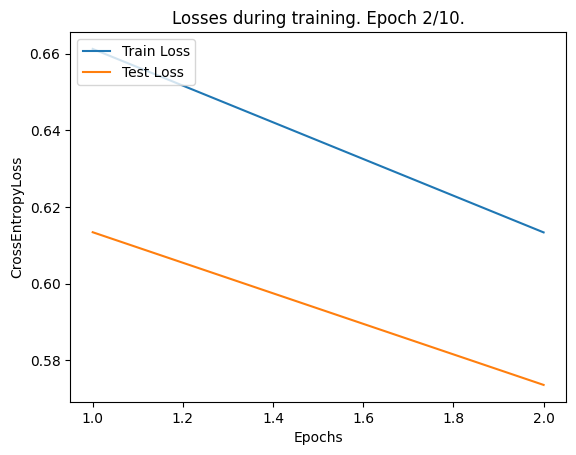

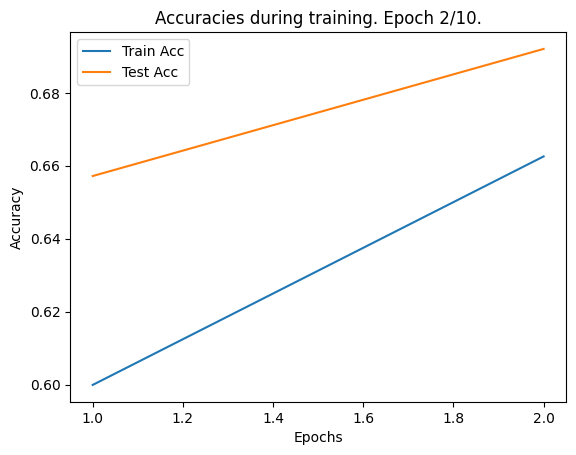

----------
Epoch Time: 4:14
Epoch 3/10
----------
--- Cur phase: train


 39%|███▉      | 273/703 [01:33<02:27,  2.91it/s, Loss=0.575227, Corrects=22/32, Accuracy=68.750%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.501783, Corrects=23/32, Accuracy=71.875%]


Calculating metrics...
train loss: 0.567145, acc: 0.702569, f05_macro: 0.702586, f1_macro: 0.702545
Confusion matrix:
[[8005 3243]
 [3448 7800]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.37it/s, Loss=0.054085, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.574116, acc: 0.698438, f05_macro: 0.705633, f1_macro: 0.687459
Confusion matrix:
[[1106  143]
 [ 610  638]]


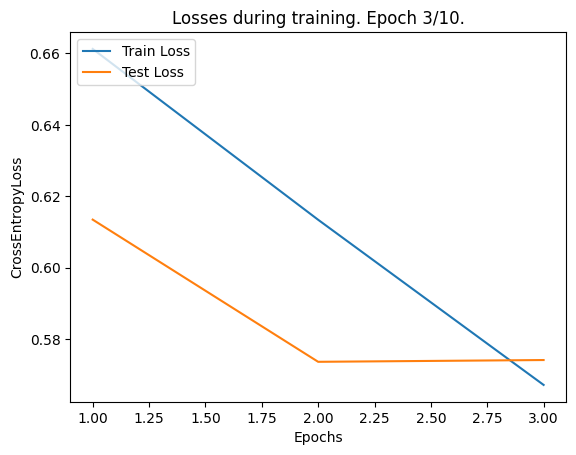

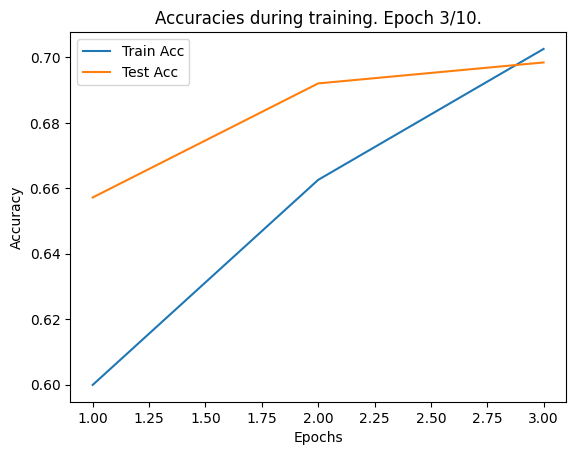

----------
Epoch Time: 4:15
Epoch 4/10
----------
--- Cur phase: train


 14%|█▍        | 98/703 [00:33<03:26,  2.93it/s, Loss=0.545445, Corrects=22/32, Accuracy=68.750%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.93it/s, Loss=0.541077, Corrects=27/32, Accuracy=84.375%]


Calculating metrics...
train loss: 0.535203, acc: 0.726396, f05_macro: 0.726443, f1_macro: 0.726346
Confusion matrix:
[[8322 2926]
 [3229 8019]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.31it/s, Loss=0.050357, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.520178, acc: 0.742891, f05_macro: 0.742916, f1_macro: 0.742873
Confusion matrix:
[[917 332]
 [310 938]]


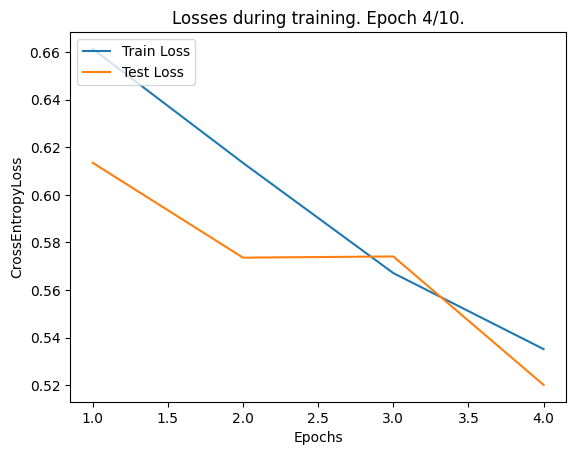

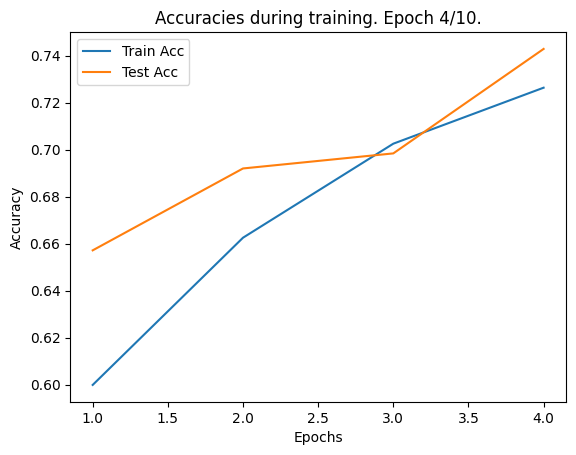

----------
Epoch Time: 4:15
Epoch 5/10
----------
--- Cur phase: train


 95%|█████████▌| 671/703 [03:49<00:10,  2.93it/s, Loss=0.514520, Corrects=23/32, Accuracy=71.875%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.391562, Corrects=25/32, Accuracy=78.125%]


Calculating metrics...
train loss: 0.509771, acc: 0.746799, f05_macro: 0.746842, f1_macro: 0.746765
Confusion matrix:
[[8531 2717]
 [2979 8269]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.52it/s, Loss=0.039665, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.510110, acc: 0.755707, f05_macro: 0.756146, f1_macro: 0.755396
Confusion matrix:
[[899 350]
 [260 988]]


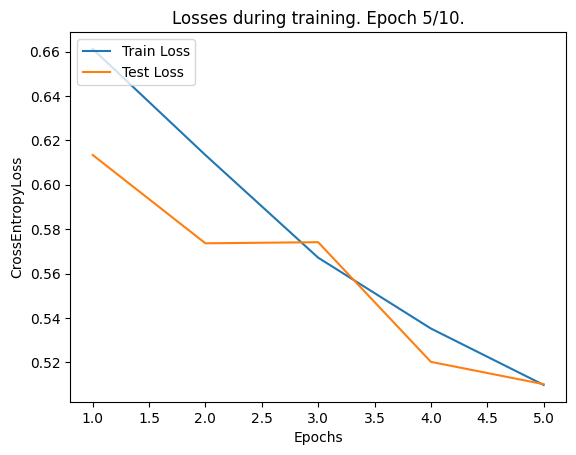

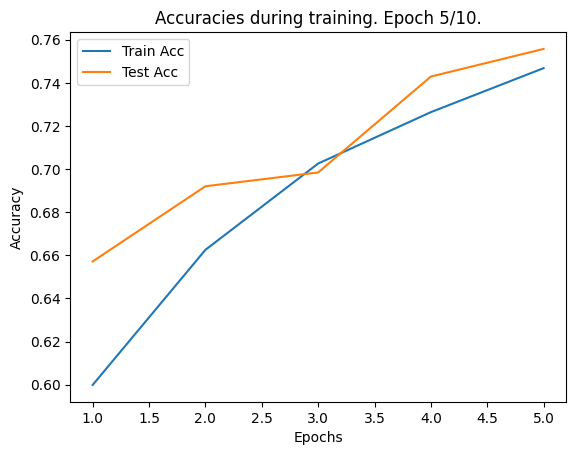

----------
Epoch Time: 4:16
Epoch 6/10
----------
--- Cur phase: train


 74%|███████▍  | 522/703 [02:59<01:02,  2.92it/s, Loss=0.384459, Corrects=28/32, Accuracy=87.500%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.404300, Corrects=27/32, Accuracy=84.375%]


Calculating metrics...
train loss: 0.492618, acc: 0.756268, f05_macro: 0.756311, f1_macro: 0.756236
Confusion matrix:
[[8635 2614]
 [2869 8378]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.46it/s, Loss=0.074041, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.503141, acc: 0.761714, f05_macro: 0.761807, f1_macro: 0.761647
Confusion matrix:
[[972 277]
 [318 930]]


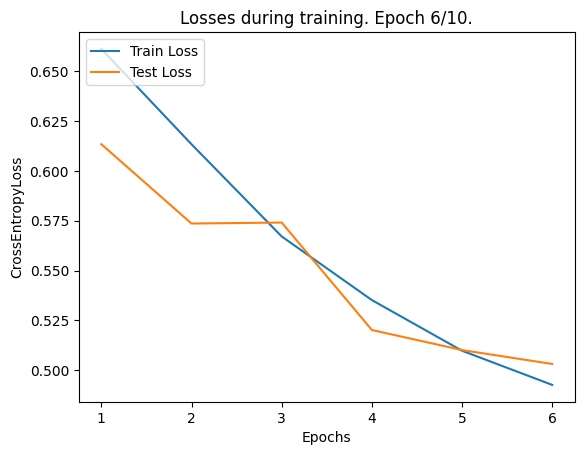

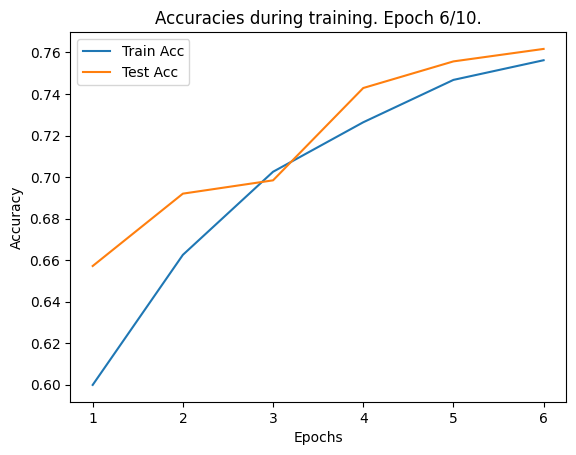

----------
Epoch Time: 4:16
Epoch 7/10
----------
--- Cur phase: train


  9%|▉         | 66/703 [00:22<03:36,  2.94it/s, Loss=0.614582, Corrects=24/32, Accuracy=75.000%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.489218, Corrects=27/32, Accuracy=84.375%]


Calculating metrics...
train loss: 0.471973, acc: 0.773738, f05_macro: 0.773778, f1_macro: 0.773713
Confusion matrix:
[[8821 2429]
 [2661 8585]]
--- Cur phase: test


100%|██████████| 79/79 [00:14<00:00,  5.28it/s, Loss=0.041719, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.494285, acc: 0.775330, f05_macro: 0.776904, f1_macro: 0.774404
Confusion matrix:
[[1048  201]
 [ 360  888]]


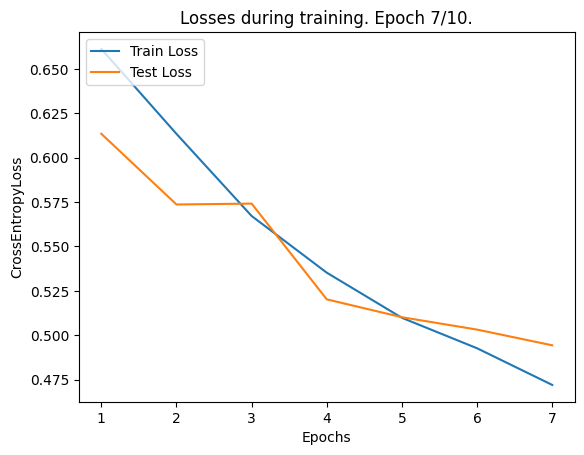

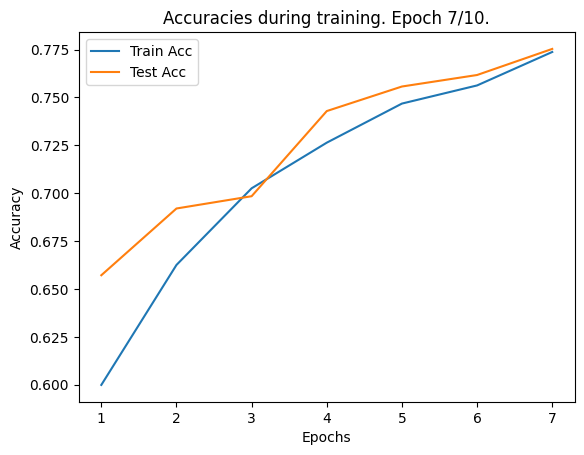

----------
Epoch Time: 4:16
Epoch 8/10
----------
--- Cur phase: train


 60%|█████▉    | 420/703 [02:23<01:35,  2.96it/s, Loss=0.374019, Corrects=26/32, Accuracy=81.250%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.289801, Corrects=28/32, Accuracy=87.500%]


Calculating metrics...
train loss: 0.455667, acc: 0.783739, f05_macro: 0.783789, f1_macro: 0.783712
Confusion matrix:
[[8941 2308]
 [2557 8690]]
--- Cur phase: test


100%|██████████| 79/79 [00:15<00:00,  5.04it/s, Loss=0.108095, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.512881, acc: 0.755707, f05_macro: 0.758615, f1_macro: 0.753635
Confusion matrix:
[[ 829  420]
 [ 190 1058]]


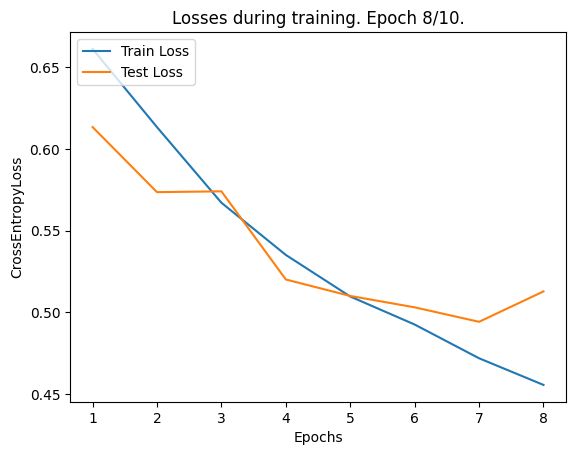

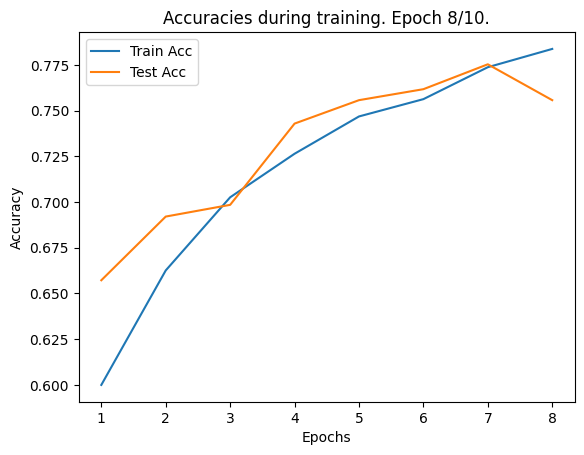

----------
Epoch Time: 4:17
Epoch 9/10
----------
--- Cur phase: train


 92%|█████████▏| 648/703 [03:41<00:18,  2.90it/s, Loss=0.398631, Corrects=28/32, Accuracy=87.500%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.513543, Corrects=25/32, Accuracy=78.125%]


Calculating metrics...
train loss: 0.441014, acc: 0.790852, f05_macro: 0.790887, f1_macro: 0.790834
Confusion matrix:
[[8998 2250]
 [2455 8793]]
--- Cur phase: test


100%|██████████| 79/79 [00:15<00:00,  5.14it/s, Loss=0.047245, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.483124, acc: 0.773328, f05_macro: 0.774094, f1_macro: 0.772863
Confusion matrix:
[[1022  227]
 [ 339  909]]


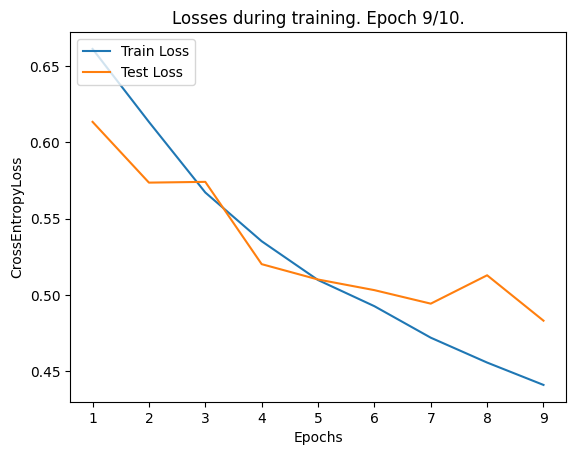

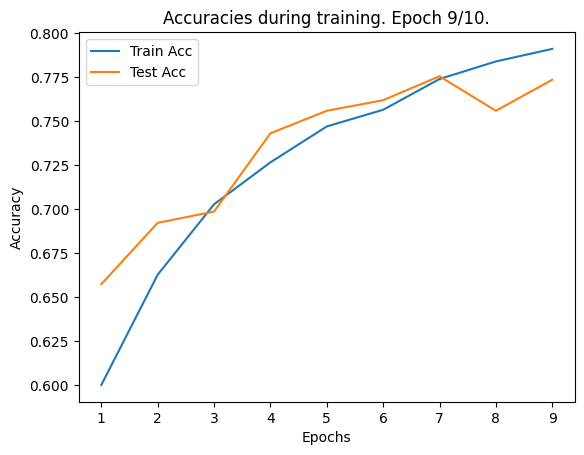

----------
Epoch Time: 4:16
Epoch 10/10
----------
--- Cur phase: train


 90%|█████████ | 634/703 [03:36<00:23,  2.94it/s, Loss=0.478133, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:00<00:00,  2.92it/s, Loss=0.428250, Corrects=26/32, Accuracy=81.250%]


Calculating metrics...
train loss: 0.426265, acc: 0.803254, f05_macro: 0.803279, f1_macro: 0.803243
Confusion matrix:
[[9119 2130]
 [2296 8951]]
--- Cur phase: test


100%|██████████| 79/79 [00:15<00:00,  4.97it/s, Loss=0.044342, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.480203, acc: 0.784541, f05_macro: 0.784544, f1_macro: 0.784541
Confusion matrix:
[[977 272]
 [266 982]]


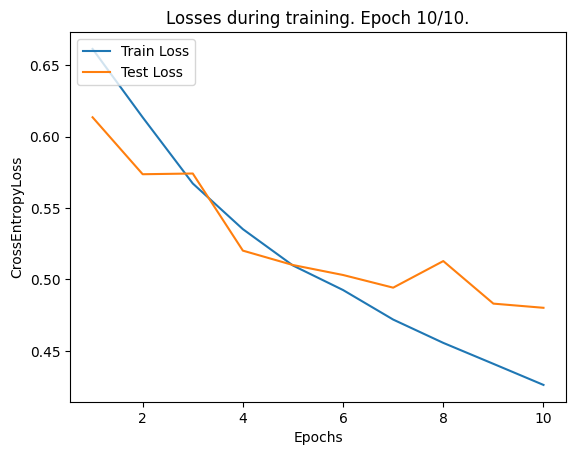

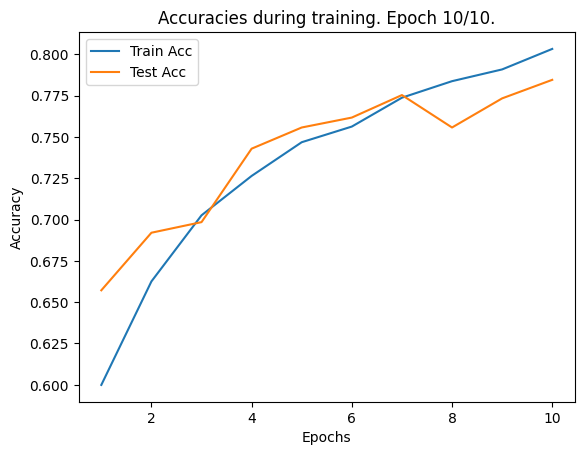

----------
Epoch Time: 4:17
*** Training Completed ***


({'train': [0.6612533949008198,
   0.6134008527395566,
   0.567145085351735,
   0.5352027857541021,
   0.5097705744323486,
   0.49261820028041875,
   0.47197266616149786,
   0.4556669164475472,
   0.44101399588127055,
   0.42626502230275914],
  'test': [0.6134439828303226,
   0.5736189208772596,
   0.5741163040393823,
   0.5201777390670218,
   0.5101104845338742,
   0.5031409182272103,
   0.4942847873835049,
   0.512880949906984,
   0.4831241708148896,
   0.48020291891028083]},
 {'train': [0.5999288762446657,
   0.6625622332859175,
   0.7025693456614509,
   0.7263958036984353,
   0.7467994310099573,
   0.7562677809388336,
   0.7737375533428165,
   0.7837393314366998,
   0.7908517069701281,
   0.8032539118065434],
  'test': [0.6571886263516219,
   0.6920304365238286,
   0.698438125750901,
   0.7428914697637164,
   0.7557068482178614,
   0.7617140568682419,
   0.775330396475771,
   0.7557068482178614,
   0.7733279935923107,
   0.7845414497396876]},
 {'train': [0.5999278516957143,
   0.66

In [ ]:
num_epochs = 10

train_model(dataloaders, num_epochs)

## ViT with nn.TransformerEncoder

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ViT_torch(nn.Module):
    def __init__(self, num_classes, channels=3, img_size=224, patch_size=16,
                 dim=768,
                 num_layers=12, num_heads=12, mlp_dim=3072, dropout=0.1):
        super(ViT_torch, self).__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Другой вариант как разбить изображение на патчи нужной размерности
        self.patch_embeddings = nn.Conv2d(in_channels=channels, out_channels=dim,
                                          kernel_size=patch_size, stride=patch_size)

        self.class_token = nn.Parameter(torch.zeros(1, 1, dim))

        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches + 1, dim))

        encoder_layers = nn.TransformerEncoderLayer(d_model=dim, nhead=num_heads,
                                                    dim_feedforward=mlp_dim,
                                                    dropout=dropout,
                                                    batch_first=True,
                                                    activation="gelu",
                                                    #norm_first=True,
                                                    )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        self.fc = nn.Linear(dim, num_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # bs x 3 x 224 x 224
        x = self.patch_embeddings(x)
        # x.shape == bs x 768 x 14 x 14
        x = x.flatten(2)
        # x.shape == bs x 768 x 196
        x = x.transpose(1, 2)
        # x.shape == bs x 196 x 768

        batch_size = x.size(0)
        class_tokens = self.class_token.expand(batch_size, -1, -1)  # bs x 1 x 768
        x = torch.cat((class_tokens, x), dim=1)
        # x.shape == bs x 197 x 768

        x += self.position_embeddings
        # x.shape == bs x 197 x 768

        x = self.transformer_encoder(x)
        # x.shape == bs x 197 x 768

        x = x[:, 0]
        # x.shape == bs x 768

        x = self.dropout(x)
        x = self.fc(x)
        # x.shape == bs x num_classes
        return x

In [ ]:
# Пример использования
model = ViT_torch(num_classes=2, channels=3, num_layers=4, num_heads=8).to(device)
input_tensor = torch.randn(1, 3, 224, 224).to(device)  # Пример входного тензора
output = model(input_tensor)
print(output.shape)  # Ожидаемый вывод: torch.Size([1, 2])

torch.Size([1, 2])


Training model with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/10
----------
--- Cur phase: train


 91%|█████████▏| 642/703 [04:10<00:24,  2.54it/s, Loss=0.712147, Corrects=12/32, Accuracy=37.500%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:34<00:00,  2.56it/s, Loss=0.599402, Corrects=21/32, Accuracy=65.625%]


Calculating metrics...
train loss: 0.685892, acc: 0.562678, f05_macro: 0.562612, f1_macro: 0.562498
Confusion matrix:
[[6557 4691]
 [5147 6101]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.20it/s, Loss=0.188735, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.652976, acc: 0.611534, f05_macro: 0.611273, f1_macro: 0.608846
Confusion matrix:
[[867 382]
 [588 660]]
----------
Epoch Time: 4:47
Epoch 2/10
----------
--- Cur phase: train


 66%|██████▌   | 463/703 [03:02<01:36,  2.50it/s, Loss=0.700701, Corrects=19/32, Accuracy=59.375%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.629107, Corrects=20/32, Accuracy=62.500%]


Calculating metrics...
train loss: 0.659439, acc: 0.593483, f05_macro: 0.593436, f1_macro: 0.593255
Confusion matrix:
[[6942 4308]
 [4837 6409]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.03it/s, Loss=0.230215, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.631939, acc: 0.627153, f05_macro: 0.627201, f1_macro: 0.621983
Confusion matrix:
[[929 320]
 [611 637]]


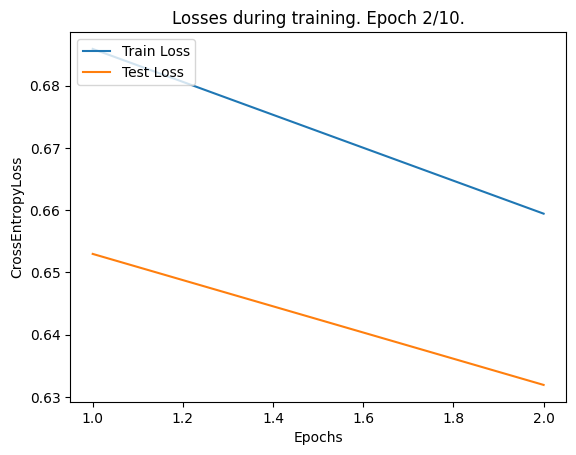

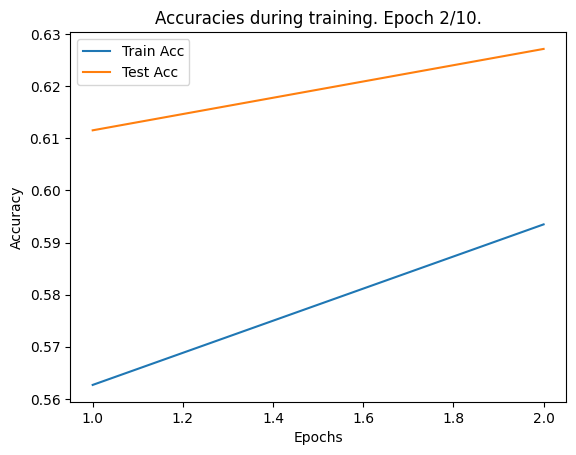

----------
Epoch Time: 4:51
Epoch 3/10
----------
--- Cur phase: train


 26%|██▌       | 183/703 [01:12<03:22,  2.57it/s, Loss=0.667635, Corrects=18/32, Accuracy=56.250%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.616756, Corrects=21/32, Accuracy=65.625%]


Calculating metrics...
train loss: 0.638192, acc: 0.622511, f05_macro: 0.622501, f1_macro: 0.622054
Confusion matrix:
[[7393 3856]
 [4636 6611]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.10it/s, Loss=0.457617, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.623269, acc: 0.637565, f05_macro: 0.637692, f1_macro: 0.635956
Confusion matrix:
[[879 370]
 [535 713]]


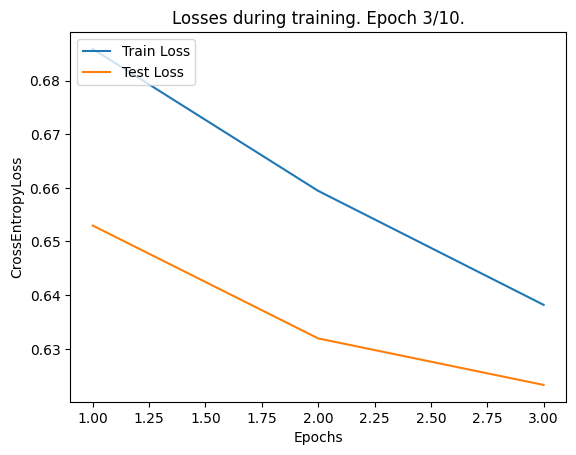

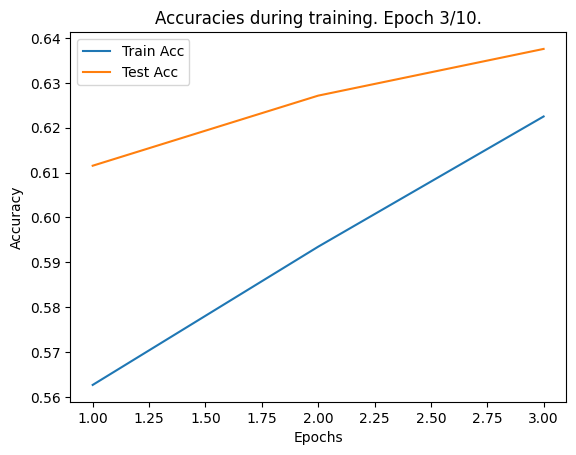

----------
Epoch Time: 4:51
Epoch 4/10
----------
--- Cur phase: train


  8%|▊         | 55/703 [00:21<04:14,  2.55it/s, Loss=0.578820, Corrects=21/32, Accuracy=65.625%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.458689, Corrects=25/32, Accuracy=78.125%]


Calculating metrics...
train loss: 0.614292, acc: 0.655317, f05_macro: 0.655391, f1_macro: 0.654979
Confusion matrix:
[[7723 3526]
 [4228 7019]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.19it/s, Loss=0.261683, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.603104, acc: 0.669203, f05_macro: 0.669408, f1_macro: 0.668639
Confusion matrix:
[[784 465]
 [361 887]]


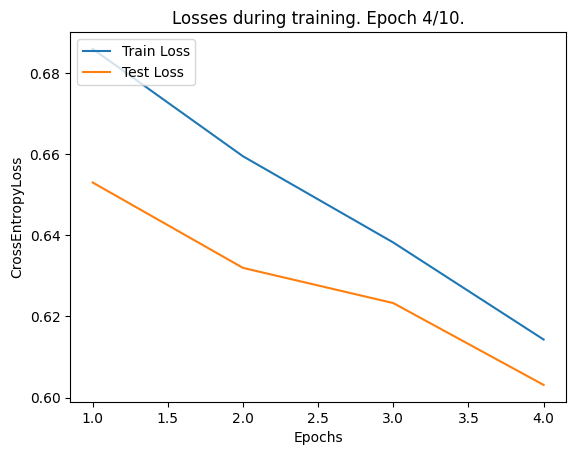

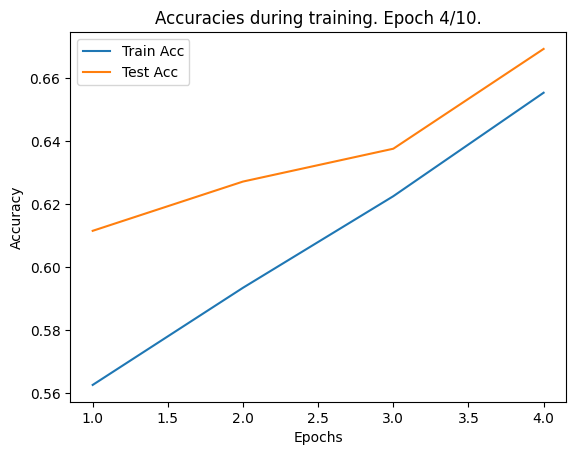

----------
Epoch Time: 4:50
Epoch 5/10
----------
--- Cur phase: train


 67%|██████▋   | 471/703 [03:05<01:31,  2.54it/s, Loss=0.764333, Corrects=17/32, Accuracy=53.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.524307, Corrects=24/32, Accuracy=75.000%]


Calculating metrics...
train loss: 0.593381, acc: 0.675765, f05_macro: 0.675831, f1_macro: 0.675591
Confusion matrix:
[[7861 3389]
 [3905 7341]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.18it/s, Loss=0.385230, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.592050, acc: 0.685623, f05_macro: 0.685642, f1_macro: 0.685577
Confusion matrix:
[[871 378]
 [407 841]]


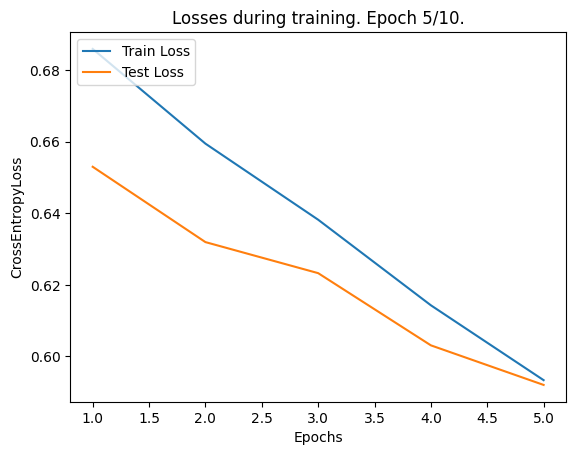

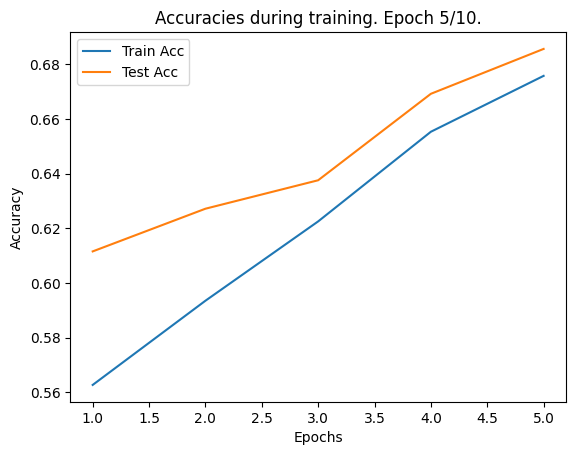

----------
Epoch Time: 4:50
Epoch 6/10
----------
--- Cur phase: train


 21%|██▏       | 150/703 [00:59<03:39,  2.52it/s, Loss=0.458795, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.595189, Corrects=25/32, Accuracy=78.125%]


Calculating metrics...
train loss: 0.573618, acc: 0.691812, f05_macro: 0.691954, f1_macro: 0.691552
Confusion matrix:
[[8108 3141]
 [3792 7455]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.11it/s, Loss=0.236773, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.581505, acc: 0.685623, f05_macro: 0.685637, f1_macro: 0.685598
Confusion matrix:
[[845 404]
 [381 867]]


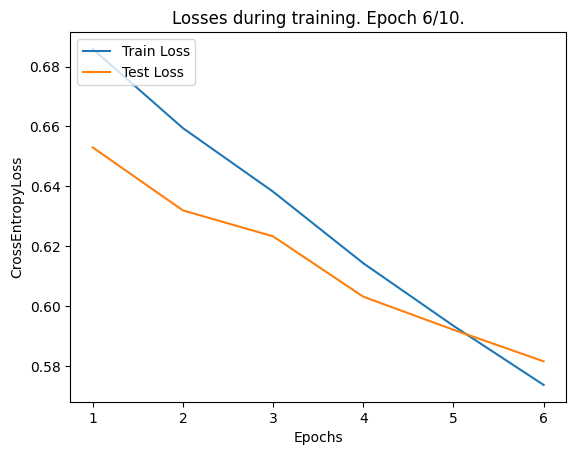

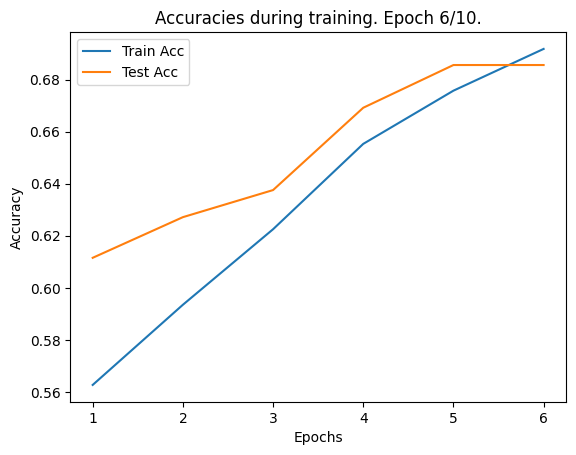

----------
Epoch Time: 4:51
Epoch 7/10
----------
--- Cur phase: train


  2%|▏         | 14/703 [00:05<04:29,  2.55it/s, Loss=0.334900, Corrects=28/32, Accuracy=87.500%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.671873, Corrects=19/32, Accuracy=59.375%]


Calculating metrics...
train loss: 0.558730, acc: 0.706303, f05_macro: 0.706413, f1_macro: 0.706145
Confusion matrix:
[[8206 3044]
 [3563 7683]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.38it/s, Loss=0.193798, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.568376, acc: 0.707249, f05_macro: 0.708889, f1_macro: 0.704958
Confusion matrix:
[[993 256]
 [475 773]]


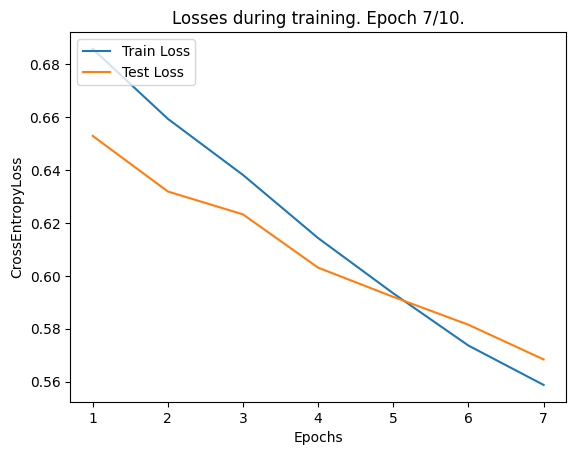

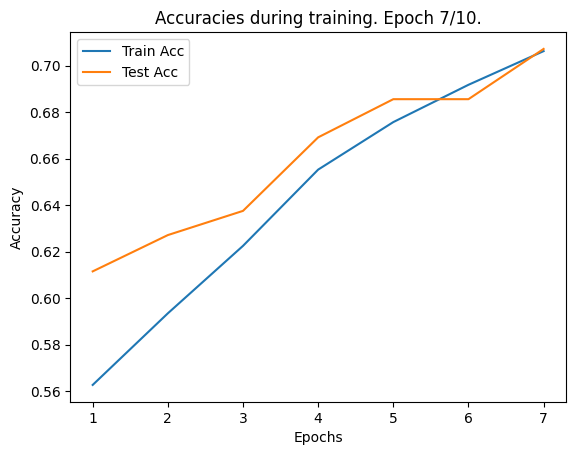

----------
Epoch Time: 4:51
Epoch 8/10
----------
--- Cur phase: train


 83%|████████▎ | 580/703 [03:48<00:48,  2.55it/s, Loss=0.462545, Corrects=24/32, Accuracy=75.000%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.508220, Corrects=26/32, Accuracy=81.250%]


Calculating metrics...
train loss: 0.541536, acc: 0.719639, f05_macro: 0.719770, f1_macro: 0.719484
Confusion matrix:
[[8359 2891]
 [3416 7830]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.19it/s, Loss=0.255128, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.563735, acc: 0.709652, f05_macro: 0.710438, f1_macro: 0.708628
Confusion matrix:
[[812 437]
 [288 960]]


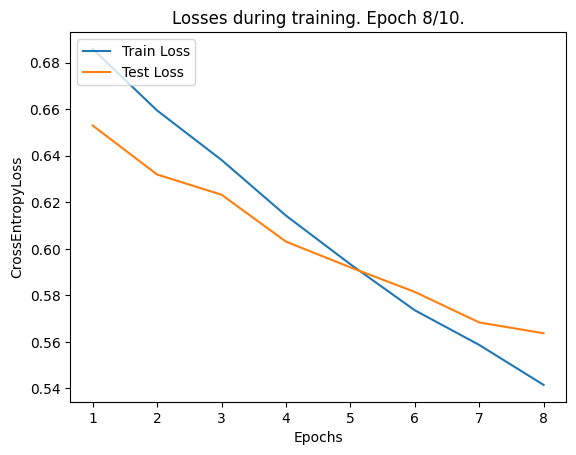

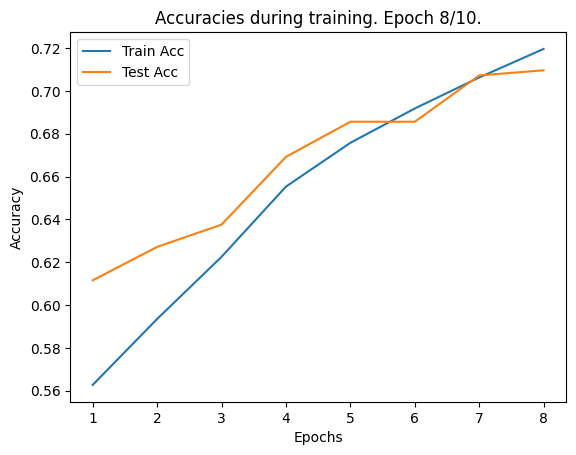

----------
Epoch Time: 4:51
Epoch 9/10
----------
--- Cur phase: train


 27%|██▋       | 187/703 [01:14<03:25,  2.51it/s, Loss=0.627048, Corrects=19/32, Accuracy=59.375%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.657994, Corrects=20/32, Accuracy=62.500%]


Calculating metrics...
train loss: 0.524393, acc: 0.733775, f05_macro: 0.733939, f1_macro: 0.733619
Confusion matrix:
[[8526 2722]
 [3267 7981]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.08it/s, Loss=0.119650, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.557120, acc: 0.707649, f05_macro: 0.707691, f1_macro: 0.707585
Confusion matrix:
[[902 347]
 [383 865]]


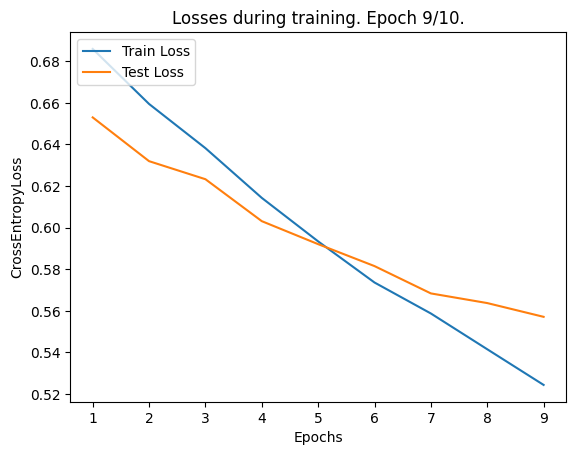

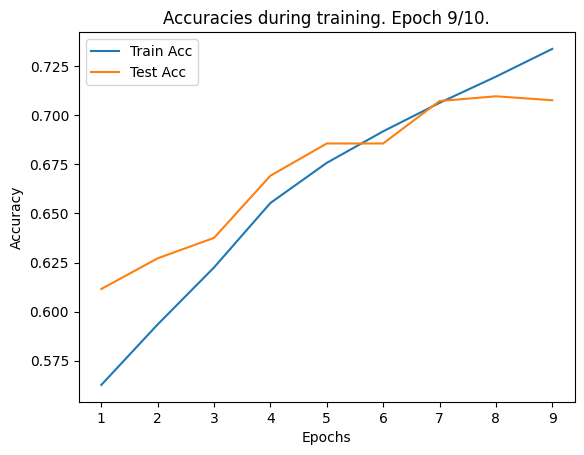

----------
Epoch Time: 4:51
Epoch 10/10
----------
--- Cur phase: train


 15%|█▌        | 108/703 [00:42<03:58,  2.49it/s, Loss=0.484491, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.518021, Corrects=22/32, Accuracy=68.750%]


Calculating metrics...
train loss: 0.510829, acc: 0.745555, f05_macro: 0.745706, f1_macro: 0.745429
Confusion matrix:
[[8636 2613]
 [3111 8136]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.32it/s, Loss=0.295587, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.592152, acc: 0.695635, f05_macro: 0.700312, f1_macro: 0.688144
Confusion matrix:
[[ 675  574]
 [ 186 1062]]


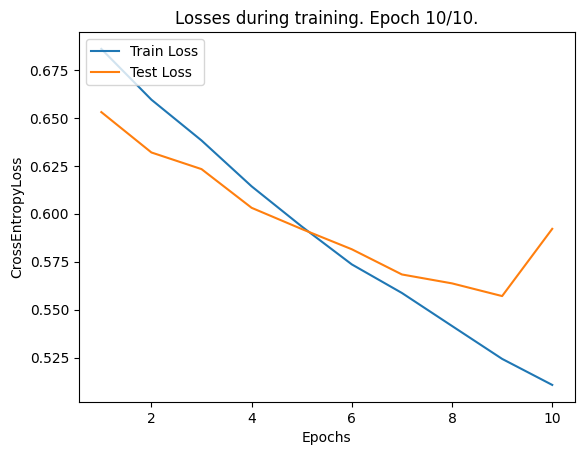

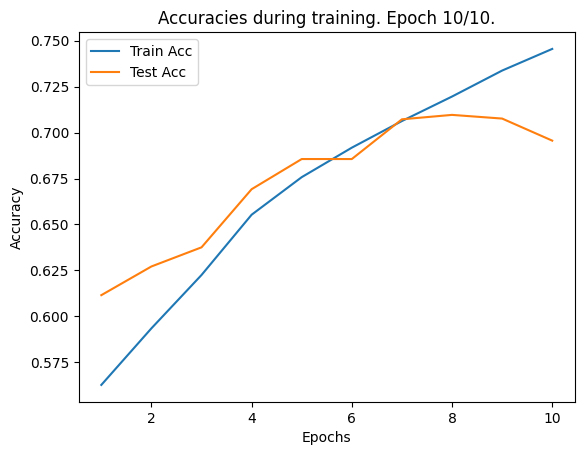

----------
Epoch Time: 4:51
*** Training Completed ***


({'train': [0.6858921233315556,
   0.6594390493538098,
   0.6381916594539224,
   0.6142915177820079,
   0.5933813281452672,
   0.5736178615015228,
   0.5587296366776375,
   0.5415357505613845,
   0.5243931615759604,
   0.5108285436928696],
  'test': [0.6529760164084509,
   0.6319386823670502,
   0.6232688989957237,
   0.6031037968280175,
   0.5920503117893045,
   0.5815053809737033,
   0.56837643697279,
   0.563735211592557,
   0.5571197794737651,
   0.5921516513461631]},
 {'train': [0.5626778093883357,
   0.5934832859174964,
   0.6225106685633002,
   0.6553165007112376,
   0.6757645803698435,
   0.6918118776671408,
   0.7063033428165008,
   0.7196390469416786,
   0.733774893314367,
   0.7455547652916074],
  'test': [0.6115338406087305,
   0.6271525830997197,
   0.6375650780937124,
   0.6692030436523828,
   0.6856227472967561,
   0.6856227472967561,
   0.7072486984381258,
   0.7096515818982779,
   0.7076491790148178,
   0.6956347617140569]},
 {'train': [0.5624980468984748,
   0.5932549

In [ ]:
import torch.optim as optim

learning_rate = 1e-5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 10

train_model(dataloaders, num_epochs)

Training model with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/10
----------
--- Cur phase: train


 86%|████████▌ | 602/703 [03:57<00:40,  2.49it/s, Loss=0.648239, Corrects=24/32, Accuracy=75.000%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.497448, Corrects=26/32, Accuracy=81.250%]


Calculating metrics...
train loss: 0.502292, acc: 0.750978, f05_macro: 0.751108, f1_macro: 0.750876
Confusion matrix:
[[8675 2575]
 [3027 8219]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.07it/s, Loss=0.041957, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.586635, acc: 0.708851, f05_macro: 0.713911, f1_macro: 0.702169
Confusion matrix:
[[1072  177]
 [ 550  698]]
----------
Epoch Time: 4:50
Epoch 2/10
----------
--- Cur phase: train


 14%|█▍        | 100/703 [00:39<03:56,  2.55it/s, Loss=0.555077, Corrects=23/32, Accuracy=71.875%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.368825, Corrects=28/32, Accuracy=87.500%]


Calculating metrics...
train loss: 0.486711, acc: 0.763069, f05_macro: 0.763186, f1_macro: 0.762989
Confusion matrix:
[[8790 2460]
 [2870 8376]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.05it/s, Loss=0.069073, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.522639, acc: 0.741290, f05_macro: 0.741343, f1_macro: 0.741239
Confusion matrix:
[[943 306]
 [340 908]]


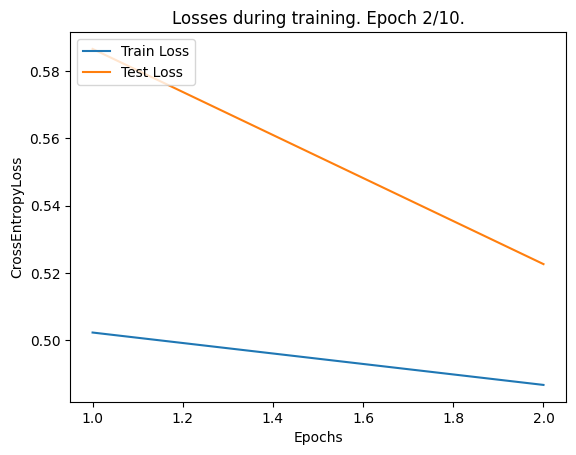

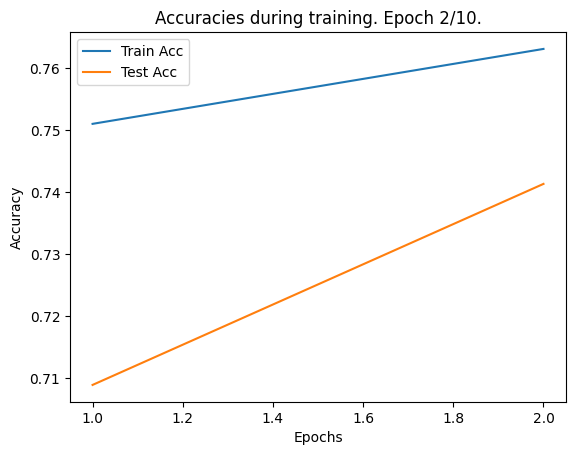

----------
Epoch Time: 4:50
Epoch 3/10
----------
--- Cur phase: train


 11%|█         | 78/703 [00:31<04:05,  2.55it/s, Loss=0.512727, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.497038, Corrects=24/32, Accuracy=75.000%]


Calculating metrics...
train loss: 0.473025, acc: 0.771337, f05_macro: 0.771502, f1_macro: 0.771236
Confusion matrix:
[[8913 2336]
 [2808 8439]]
--- Cur phase: test


100%|██████████| 79/79 [00:12<00:00,  6.15it/s, Loss=0.079438, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.526878, acc: 0.738887, f05_macro: 0.740630, f1_macro: 0.737317
Confusion matrix:
[[1019  230]
 [ 422  826]]


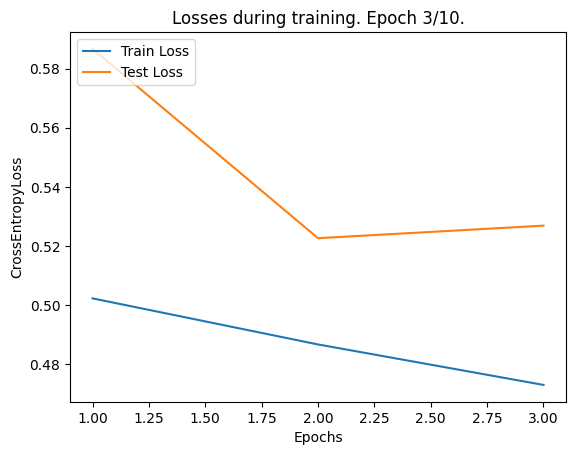

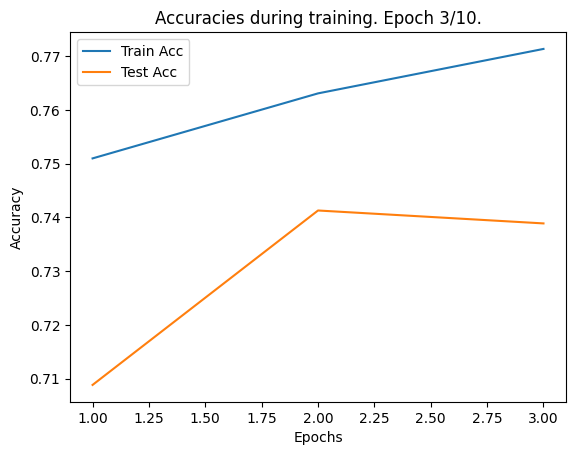

----------
Epoch Time: 4:50
Epoch 4/10
----------
--- Cur phase: train


 53%|█████▎    | 370/703 [02:26<02:10,  2.55it/s, Loss=0.229126, Corrects=30/32, Accuracy=93.750%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.538504, Corrects=25/32, Accuracy=78.125%]


Calculating metrics...
train loss: 0.464305, acc: 0.778627, f05_macro: 0.778732, f1_macro: 0.778567
Confusion matrix:
[[8944 2306]
 [2674 8572]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.03it/s, Loss=0.065325, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.518929, acc: 0.742491, f05_macro: 0.742538, f1_macro: 0.742454
Confusion matrix:
[[912 337]
 [306 942]]


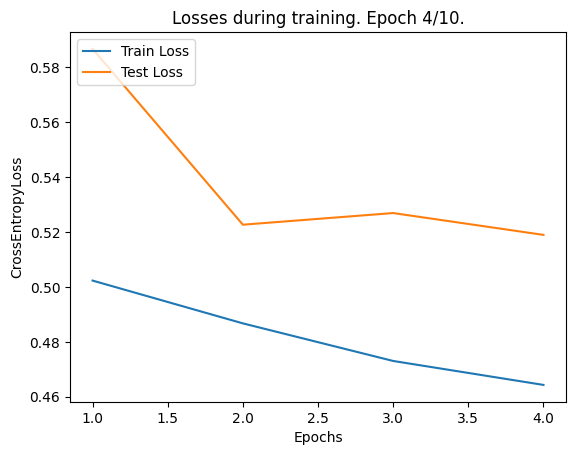

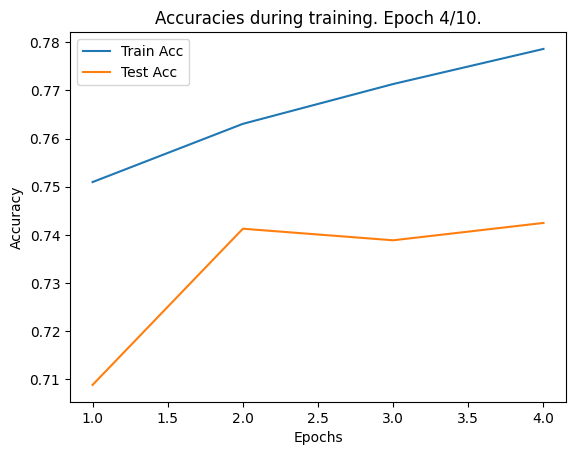

----------
Epoch Time: 4:51
Epoch 5/10
----------
--- Cur phase: train


 91%|█████████▏| 642/703 [04:13<00:23,  2.55it/s, Loss=0.470293, Corrects=26/32, Accuracy=81.250%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.348281, Corrects=29/32, Accuracy=90.625%]


Calculating metrics...
train loss: 0.449378, acc: 0.788629, f05_macro: 0.788734, f1_macro: 0.788575
Confusion matrix:
[[9051 2199]
 [2556 8690]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  5.97it/s, Loss=0.047570, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.538832, acc: 0.744493, f05_macro: 0.744493, f1_macro: 0.744493
Confusion matrix:
[[930 319]
 [319 929]]


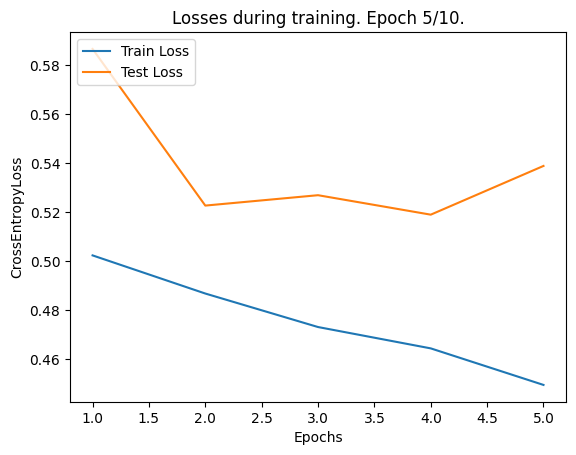

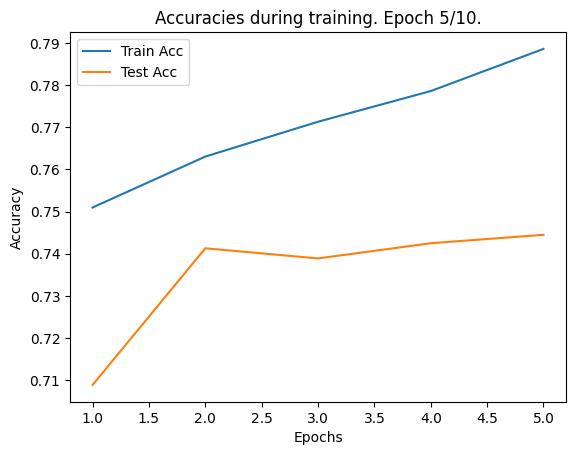

----------
Epoch Time: 4:51
Epoch 6/10
----------
--- Cur phase: train


 64%|██████▎   | 448/703 [02:56<01:40,  2.54it/s, Loss=0.404479, Corrects=27/32, Accuracy=84.375%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.54it/s, Loss=0.343166, Corrects=28/32, Accuracy=87.500%]


Calculating metrics...
train loss: 0.441820, acc: 0.793385, f05_macro: 0.793470, f1_macro: 0.793345
Confusion matrix:
[[9081 2167]
 [2481 8767]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  5.98it/s, Loss=0.059304, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.524852, acc: 0.741290, f05_macro: 0.741853, f1_macro: 0.740814
Confusion matrix:
[[872 377]
 [269 979]]


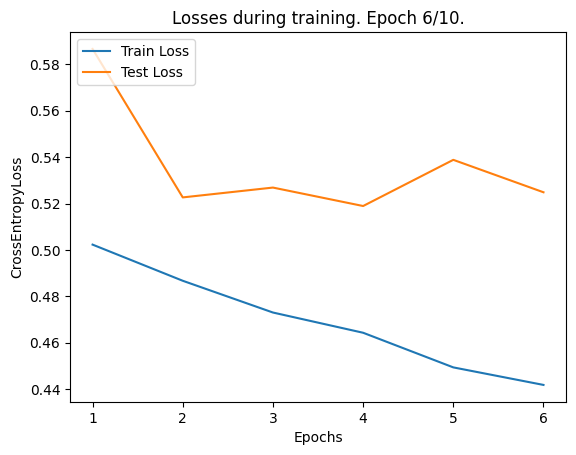

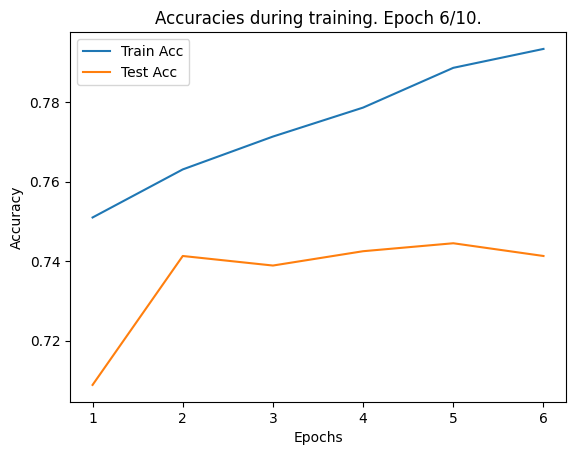

----------
Epoch Time: 4:51
Epoch 7/10
----------
--- Cur phase: train


 64%|██████▍   | 452/703 [02:58<01:38,  2.54it/s, Loss=0.601655, Corrects=21/32, Accuracy=65.625%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.310649, Corrects=28/32, Accuracy=87.500%]


Calculating metrics...
train loss: 0.428805, acc: 0.799253, f05_macro: 0.799377, f1_macro: 0.799197
Confusion matrix:
[[9178 2071]
 [2445 8802]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  5.92it/s, Loss=0.043205, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.519764, acc: 0.748498, f05_macro: 0.748837, f1_macro: 0.748220
Confusion matrix:
[[976 273]
 [355 893]]


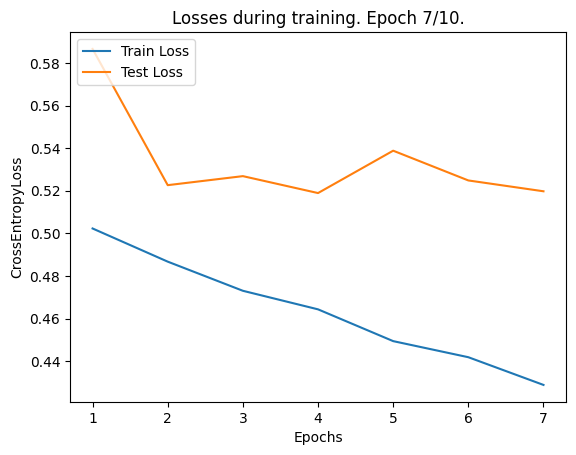

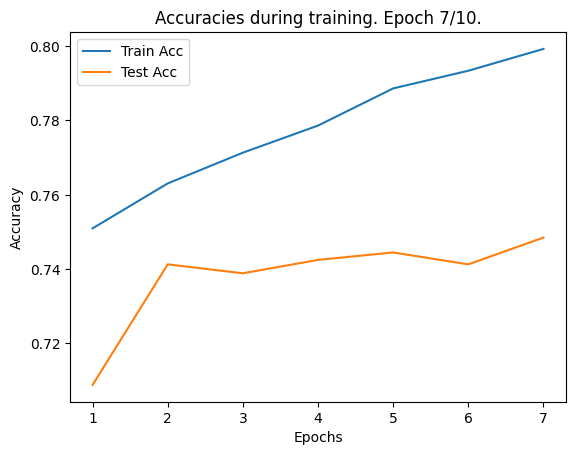

----------
Epoch Time: 4:51
Epoch 8/10
----------
--- Cur phase: train


 50%|████▉     | 351/703 [02:18<02:19,  2.52it/s, Loss=0.568458, Corrects=24/32, Accuracy=75.000%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.344988, Corrects=28/32, Accuracy=87.500%]


Calculating metrics...
train loss: 0.419120, acc: 0.804854, f05_macro: 0.804950, f1_macro: 0.804814
Confusion matrix:
[[9215 2033]
 [2357 8891]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  5.86it/s, Loss=0.034476, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.510895, acc: 0.758110, f05_macro: 0.758127, f1_macro: 0.758096
Confusion matrix:
[[956 293]
 [311 937]]


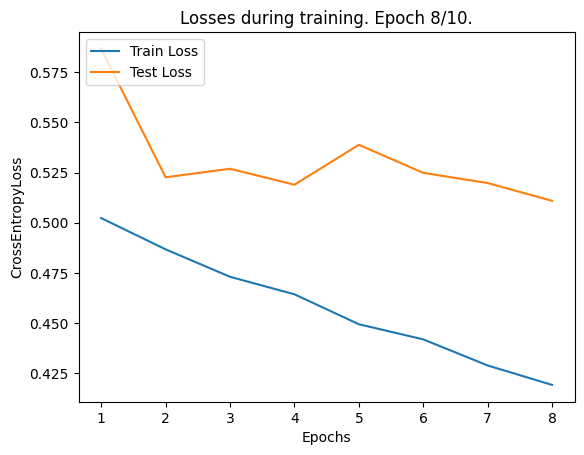

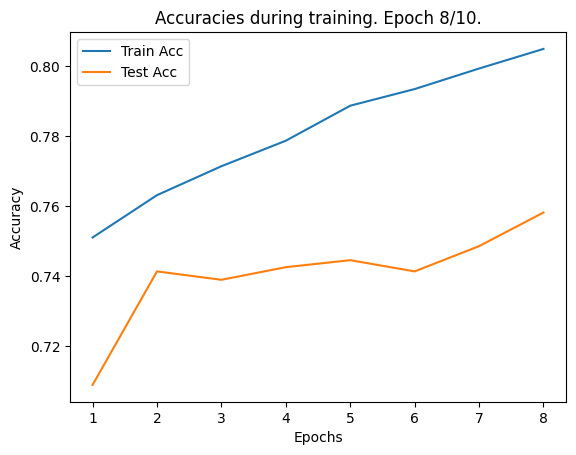

----------
Epoch Time: 4:51
Epoch 9/10
----------
--- Cur phase: train


 44%|████▍     | 311/703 [02:03<02:33,  2.55it/s, Loss=0.437674, Corrects=25/32, Accuracy=78.125%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:38<00:00,  2.52it/s, Loss=0.546852, Corrects=22/32, Accuracy=68.750%]


Calculating metrics...
train loss: 0.407734, acc: 0.812678, f05_macro: 0.812768, f1_macro: 0.812642
Confusion matrix:
[[9297 1953]
 [2261 8985]]
--- Cur phase: test


100%|██████████| 79/79 [00:16<00:00,  4.85it/s, Loss=0.022738, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.523023, acc: 0.753704, f05_macro: 0.753770, f1_macro: 0.753659
Confusion matrix:
[[924 325]
 [290 958]]


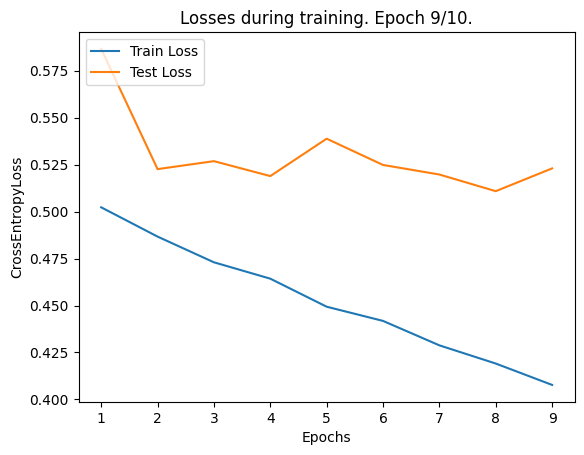

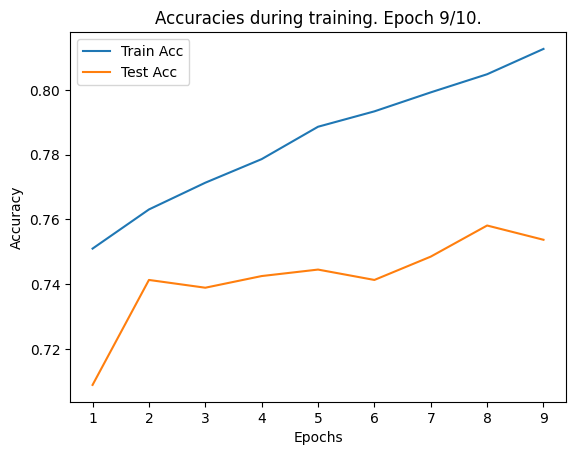

----------
Epoch Time: 4:56
Epoch 10/10
----------
--- Cur phase: train


 62%|██████▏   | 434/703 [02:51<01:46,  2.52it/s, Loss=0.235081, Corrects=31/32, Accuracy=96.875%]/usr/local/lib/python3.10/dist-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 703/703 [04:37<00:00,  2.53it/s, Loss=0.293663, Corrects=30/32, Accuracy=93.750%]


Calculating metrics...
train loss: 0.392356, acc: 0.823124, f05_macro: 0.823242, f1_macro: 0.823082
Confusion matrix:
[[9432 1818]
 [2161 9085]]
--- Cur phase: test


100%|██████████| 79/79 [00:13<00:00,  6.00it/s, Loss=0.058463, Corrects=1/1, Accuracy=100.000%]


Calculating metrics...
test loss: 0.542535, acc: 0.753304, f05_macro: 0.753335, f1_macro: 0.753283
Confusion matrix:
[[929 320]
 [296 952]]


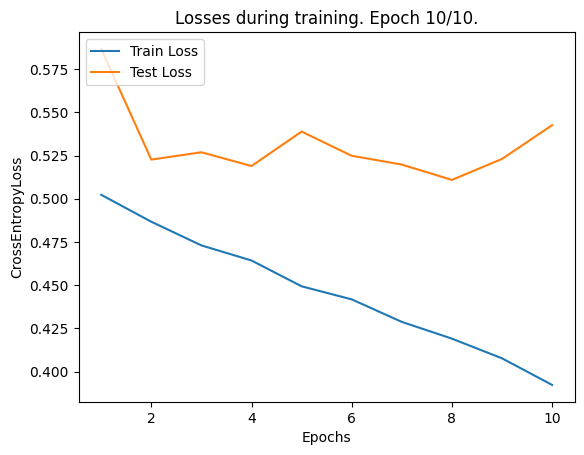

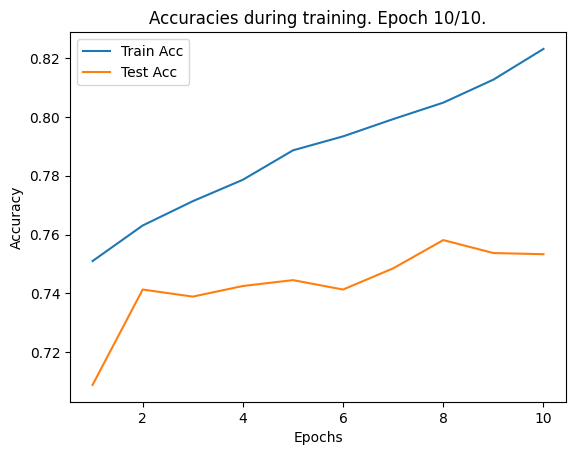

----------
Epoch Time: 4:51
*** Training Completed ***


({'train': [0.5022919526903931,
   0.48671106076342285,
   0.4730246040975386,
   0.4643045470733222,
   0.4493775826853675,
   0.4418203772216569,
   0.42880478948566686,
   0.4191196687614935,
   0.40773376175977427,
   0.3923555129071218],
  'test': [0.5866352470056816,
   0.5226386660694312,
   0.5268782583573698,
   0.5189285163443519,
   0.5388315921581455,
   0.5248518668899882,
   0.519763674097666,
   0.5108948338629128,
   0.5230225494573796,
   0.5425354410298572]},
 {'train': [0.7509779516358464,
   0.7630689900426743,
   0.7713371266002845,
   0.7786273115220483,
   0.7886290896159317,
   0.7933854907539118,
   0.7992532005689901,
   0.8048541963015647,
   0.8126778093883357,
   0.8231241109530584],
  'test': [0.7088506207448939,
   0.7412895474569483,
   0.7388866639967961,
   0.7424909891870244,
   0.7444933920704846,
   0.7412895474569483,
   0.7484981978374049,
   0.7581097316780137,
   0.7537044453344013,
   0.7533039647577092]},
 {'train': [0.750875590437615,
   0.76

In [ ]:
train_model(dataloaders, num_epochs)